In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.integrate import odeint #usar solve_ivp talvez
#from matplotlib.lines import Line2D

In [2]:
#choose your f
f_choice = 1

shift = np.array([128., -56.]) #8, -6

if f_choice == 1:
    def f(x):
        return (x[0] - shift[0])**2 + (x[1] - shift[1])**2 + (x[0] - shift[0])*(x[1] - shift[1])
    
    def grad_f(x):
        return np.array([2*(x[0] - shift[0]) + x[1] - shift[1], 2*(x[1] - shift[1]) + x[0] - shift[0]])

elif f_choice == 2:
    def f(x):
        return np.exp(x[0] - shift[0]) + np.exp(x[1] - shift[1]) - x[0] + shift[0] - x[1] + shift[1]

    def grad_f(x):
        return np.array([np.exp(x[0] - shift[0]) - 1, np.exp(x[1] - shift[1]) - 1])
        
# elif f_choice == 3:
#     def f(x):
#         return x[0] * np.log( (x[0] / a)) + x[1] * np.log( (x[1] / b)) + c * (x[0]**2 + x[1]**2)

#     def grad_f(x):
#         return np.array([np.log( (x[0] / a) ) + (1/a) + c * 2* x[0], np.log( (x[1] / b) ) + (1/b) + c * 2* x[1]])

In [3]:
#choose your phi
phi_choice = 4

a = 1
b = 1
c = 1.5

if phi_choice == 1: #euclidiano
    def phi(x):
        return 0.5*((x[0])**2 + (x[1])**2)
    
    def grad_phi(x):
        return np.array([x[0], x[1]])
    
    def inv_grad_phi(y):
        return np.array([y[0], y[1]])
    
elif phi_choice == 2:
    def phi(x):
        return (x[0])**2 + (x[1])**2 - x[0] * x[1]
    
    def grad_phi(x):
        return np.array([2*(x[0]) - x[1], 2*(x[1]) - x[0]])
    
    def inv_grad_phi(y):
        return np.array([ ( 2 * y[0] + y[1]) / 3 , ( 2 * y[1] + y[0]) / 3])

elif phi_choice == 3:
    def phi(x):
        return np.exp(x[0]) + np.exp(-x[0]) + np.exp(x[1]) + np.exp(-x[1])
    
    def grad_phi(x):
        return np.array([np.exp(x[0]) - np.exp(-x[0]), np.exp(x[1]) - np.exp(-x[1])])

    def inv_grad_phi_aux(x):
        return np.log((x+np.sqrt(x**2 + 4))/2)
    
    def inv_grad_phi(y):
        return np.array([inv_grad_phi_aux(y[0]), inv_grad_phi_aux(y[1])])
        
elif phi_choice == 4:
    def phi(x):
        return a * x[0]**2 + b * x[1]**2 +  c * x[0] * x[1]

    def grad_phi(x):
        return np.array([2 * a * x[0] + c * x[1], 2 * b * x[1] + c* x[0]])

    def inv_grad_phi(y):
        denom = 4 * a * b - c**2
        return np.array([ (2 * b * y[0] - c * y[1])/denom , (2 * a * y[1] - c * y[0])/denom])

elif phi_choice == 5:
    def phi(x):
        return x[0] * np.log(x[0]) + x[1] * np.log(x[1])

    def grad_phi(x):
        return np.array([np.log(x[0]) + 1, np.log(x[1]) + 1 ])

    def inv_grad_phi(y):
        return np.array([np.exp(y[0] - 1), np.exp(y[1] - 1)])

In [4]:
#parâmetros
eta = 0.05  # taxa de aprendizado
k = 2      # parâmetro para mu. k=1 => (k-1)/(k+2)=0, k=2 => (k-1)/(k+2)=1/4
number_of_iterations = 100

xopt = np.array([0.,0.])+shift
thetaopt = grad_phi(xopt)
xopt_phi = inv_grad_phi([0.,0.])

#pontos iniciais
theta0 = np.array([0., 0.])
x0 = inv_grad_phi(theta0) #np.array([1.25, 0.75])
y0 = x0
x1 = y0 - eta * grad_f(y0)
#theta0 = grad_phi(x0)
theta1 = theta0 - eta * grad_f(x0)
Mx1 = inv_grad_phi(theta1)
z0 = theta0

GD_points  = [x0, x1]

AGD_x_points = [x0, x1]
AGD_y_points = [y0]

MD_x_points     = [x0, Mx1]
MD_theta_points = [theta0, theta1]

AMD1_x_points     = [x0, Mx1]
AMD1_theta_points = [theta0, theta1]
AMD1_xi_points    = [theta0]

AMD2_x_points     = [x0, Mx1]
AMD2_y_points     = [y0]
AMD2_theta_points = [theta0, theta1]

AMDalt_x_points = [x0]
AMDalt_z_points = [z0]

for i in range(number_of_iterations):

    mu_k = (k-1)/(k+2)
    lambda_k = 3/(k+3)
    
    x1 = GD_points[-1] - eta * grad_f(GD_points[-1])
    GD_points.append(x1)

    y1 = AGD_x_points[-1] + mu_k * (AGD_x_points[-1] - AGD_x_points[-2])
    AGD_y_points.append(y1)
    x1 = y1 - eta * grad_f(y1)
    AGD_x_points.append(x1)

    theta1 = MD_theta_points[-1] - eta * grad_f(MD_x_points[-1])
    MD_theta_points.append(theta1)
    Mx1 = inv_grad_phi(theta1)
    MD_x_points.append(Mx1)

    xi1 = AMD1_theta_points[-1] + mu_k * (AMD1_theta_points[-1] - AMD1_theta_points[-2])
    AMD1_xi_points.append(xi1)
    theta1 = xi1 - eta * grad_f(AMD1_x_points[-1])
    # ou theta1 = xi1 - eta * grad_f(inv_grad_phi(xi1))
    AMD1_theta_points.append(theta1)
    x1 = inv_grad_phi(theta1)
    AMD1_x_points.append(x1)

    y1 = AMD2_x_points[-1] + mu_k * (AMD2_x_points[-1] - AMD2_x_points[-2])
    AMD2_y_points.append(y1)
    theta1 = grad_phi(y1) - eta * grad_f(y1)
    AMD2_theta_points.append(theta1)
    x1 = inv_grad_phi(theta1)
    AMD2_x_points.append(x1)

    x1 = lambda_k * inv_grad_phi(AMDalt_z_points[-1]) + (1 - lambda_k) * AMDalt_x_points[-1]
    AMDalt_x_points.append(x1)
    z1 = AMDalt_z_points[-1] - ((k*eta)/3) * grad_f(x1)
    AMDalt_z_points.append(z1)

    k += 1

GD_points  = np.array(GD_points)

AGD_x_points = np.array(AGD_x_points)
AGD_y_points = np.array(AGD_y_points)

MD_x_points     = np.array(MD_x_points)
MD_theta_points = np.array(MD_theta_points)

AMD1_x_points     = np.array(AMD1_x_points)
AMD1_theta_points = np.array(AMD1_theta_points)
AMD1_xi_points    = np.array(AMD1_xi_points)

AMD2_x_points     = np.array(AMD2_x_points)
AMD2_y_points     = np.array(AMD2_y_points)
AMD2_theta_points = np.array(AMD2_theta_points)

AMDalt_x_points = np.array(AMDalt_x_points)
AMDalt_z_points = np.array(AMDalt_z_points) #isso não me traz muita informação, então não vou plotar e portanto, vou passar a ignorar a partir daqui

In [5]:
# EDO para GD
def GD_ode(state, t):
    dxdt, dydt = - grad_f(state)
    return [dxdt, dydt]

# EDO para AGD
def AGD_ode(state, t):
    x, y, vx, vy = state
    dxdt = vx
    dydt = vy
    dvxdt = - (3/t) * vx - grad_f([x, y])[0]
    dvydt = - (3/t) * vy - grad_f([x, y])[1]
    return [dxdt, dydt, dvxdt, dvydt]
    return [dxdt, dydt]

# EDO para MD
def MD_ode(state, t):
    x = inv_grad_phi(state)
    dtheta_xdt, dtheta_ydt = -grad_f(x)
    return [dtheta_xdt, dtheta_ydt]

# EDO para AMD
def AMD1_ode(state, t):
    theta1, theta2, vtheta1, vtheta2 = state
    dtheta1dt = vtheta1
    dtheta2dt = vtheta2
    x,y = inv_grad_phi([theta1, theta2])
    dvtheta1dt = - (3/t) * vtheta1 - grad_f([x, y])[0]
    dvtheta2dt = - (3/t) * vtheta2 - grad_f([x, y])[1]
    return [dtheta1dt, dtheta2dt, dvtheta1dt, dvtheta2dt]

# EDO para AMD Krichene
def AMDalt_ode(state, t):
    x, y, z1, z2 = state
    u1, u2 = inv_grad_phi([z1,z2]) # grad_phi([z1,z2])
    dx = (3/t)*(u1 - x)
    dy = (3/t)*(u2 - y)
    v1, v2 = grad_f([x,y])
    dz1 = -(t/3)*v1
    dz2 = -(t/3)*v2
    return [dx, dy, dz1, dz2]

In [6]:
# Tempo para integração
t = np.linspace(0+1/100, 20, 1000)

# Solução da EDO para GD
sol_primal_gd = odeint(GD_ode, x0, t)

# Solução da EDO para AGD
sol_primal_agd = odeint(AGD_ode, [x0[0], x0[1], 0, 0], t)

# Solução da EDO para MD
sol_dual_md = odeint(MD_ode, theta0, t)

sol_primal_md = inv_grad_phi(sol_dual_md.transpose()).transpose()

# Solução da EDO para AMD
sol_dual_amd = odeint(AMD1_ode, [theta0[0], theta0[1], 0, 0], t)

sol_primal_amd = inv_grad_phi(sol_dual_amd.transpose()).transpose()

# Solução da EDO para AMD Krichene

sol_amd_alt = odeint(AMDalt_ode, [x0[0], x0[1], theta0[0], theta0[1]], t)[:,0:2]

In [7]:
# Range para o espaço primal (x e y)
primal_points = np.vstack([GD_points, AGD_x_points, AGD_y_points, MD_x_points, AMD1_x_points, AMD2_x_points, AMD2_y_points, AMDalt_x_points])

x_coords = primal_points[:,0]
y_coords = primal_points[:,1]
primal_padding = max( max(x_coords) - min(x_coords), max(y_coords) - min(y_coords)) * 0.05
x_range = (min(x_coords) - primal_padding, max(x_coords) + primal_padding)
y_range = (min(y_coords) - primal_padding, max(y_coords) + primal_padding)

# Range para o espaço dual (theta e xi)
dual_points = np.vstack([MD_theta_points ,AMD1_theta_points, AMD1_xi_points, AMD2_theta_points, AMDalt_z_points, np.array([0., 0.])]) #

theta1_coords = dual_points[:,0]
theta2_coords = dual_points[:,1]
dual_padding = max( max(theta1_coords) - min(theta1_coords), max(theta2_coords) - min(theta2_coords)) * 0.05
theta1_range = (min(theta1_coords) - dual_padding, max(theta1_coords) + dual_padding)
theta2_range = (min(theta2_coords) - dual_padding, max(theta2_coords) + dual_padding)

In [8]:
def plota_métodos(methods, nomes, curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal):

    dual_space = 'MD' in methods or 'AMD1' in methods or 'AMD2' in methods
    
    if dual_space:
        fig, (ax_primal, ax_dual) = plt.subplots(1, 2, figsize=(20, 10))
    
        if curvas_de_nível_f_dual:
            theta1grid = np.linspace(theta1_range[0], theta1_range[1], 100)
            theta2grid = np.linspace(theta2_range[0], theta2_range[1], 100)
            Theta1, Theta2 = np.meshgrid(theta1grid, theta2grid)
            corners_dual = [[i,j] for i in theta1_range for j in theta2_range]
            
            Z_f_dual = f(inv_grad_phi([Theta1, Theta2]))
            Z_f_dual_max = max([f(inv_grad_phi(corner)) for corner in corners_dual])
            
            ax_dual.contour(Theta1, Theta2, Z_f_dual, levels=np.linspace(0, Z_f_dual_max, 20), cmap='plasma')
        
        #theta_0_plot     = ax_dual.scatter(theta0[0], theta0[1], color='k', s=150, label='theta_0', zorder=5)
        origem_dual_plot = ax_dual.scatter(0., 0., color='k', s=150, label='origem', zorder=5)
        theta_opt_plot   = ax_dual.scatter(thetaopt[0], thetaopt[1], color='gold', s=250, marker='*',edgecolors='red', label='ponto ótimo', zorder=5)
    
        #plot MD
        if 'MD' in methods:
            MD_pontos_primal_plot = ax_primal.scatter(MD_x_points[:,0], MD_x_points[:,1], s=100, c=colors['MD'], label='MD', zorder=4)
            MD_x_arrows = MD_x_points[1:] - MD_x_points[0:-1]
            ax_primal.quiver(MD_x_points[0:-1,0], MD_x_points[0:-1,1], MD_x_arrows[:,0], MD_x_arrows[:,1], angles='xy', scale_units='xy', color=colors['MD'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
            MD_pontos_dual_plot = ax_dual.scatter(MD_theta_points[:,0], MD_theta_points[:,1], color=colors['MD'], s=100, label='MD', zorder=4)
            MD_theta_arrows = MD_theta_points[1:] - MD_theta_points[0:-1]
            ax_dual.quiver(MD_theta_points[0:-1,0], MD_theta_points[0:-1,1], MD_theta_arrows[:,0], MD_theta_arrows[:,1], angles='xy', scale_units='xy', color=colors['MD'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
        
        #plot AMD
        if 'AMD1' in methods:
            AMD1_pontos_primal_plot = ax_primal.scatter(AMD1_x_points[:,0], AMD1_x_points[:,1], marker =  "D", color=colors['AMD1'], s=100, label='AMD1', zorder=4)
            AMD1_x_arrows = AMD1_x_points[1:] - AMD1_x_points[0:-1]
            ax_primal.quiver(AMD1_x_points[0:-1,0], AMD1_x_points[0:-1,1], AMD1_x_arrows[:,0], AMD1_x_arrows[:,1], angles='xy', scale_units='xy', color=colors['AMD1'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
    
            AMD1_pontos_dual_plot = ax_dual.scatter(AMD1_theta_points[:,0], AMD1_theta_points[:,1], marker =  "D", color=colors['AMD1'], s=100, label='AMD1', zorder=4)
            #ax_dual.scatter(AMD1_xi_points[:,0], AMD1_xi_points[:,1], color=colors['AMD1_aux'], s=100, zorder=3)
            AMD1_arrows_theta0_to_theta1 = AMD1_theta_points[1:] - AMD1_theta_points[0:-1]
            ax_dual.quiver(AMD1_theta_points[0:-1,0], AMD1_theta_points[0:-1,1], AMD1_arrows_theta0_to_theta1[:,0], AMD1_arrows_theta0_to_theta1[:,1], angles='xy', scale_units='xy', color=colors['AMD1'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
            
            #AMD1_segments_theta0_to_xi0    = [[AMD1_xi_points[i],   AMD1_theta_points[i]] for i in range(number_of_iterations+1)]#AMD_xi_points[0:] - AMD_theta_points[0:-1]
            #AMD1_segments_xi0_to_theta1    = [[AMD1_theta_points[i+1], AMD1_xi_points[i]] for i in range(number_of_iterations+1)]# AMD_theta_points[1:] - AMD_xi_points[0:]
    
            #lc_theta0_to_xi0 = LineCollection(AMD1_segments_theta0_to_xi0, linestyles=estilo_segmentos_aux['linestyle'], colors=colors['AMD1'])
            #ax_dual.add_collection(lc_theta0_to_xi0)
            #lc_xi0_to_theta1 = LineCollection(AMD1_segments_xi0_to_theta1, linestyles=estilo_segmentos_aux['linestyle'], colors=colors['AMD1'])
            #ax_dual.add_collection(lc_xi0_to_theta1)

                #plot AMD
        if 'AMD2' in methods:
            AMD2_pontos_primal_plot = ax_primal.scatter(AMD2_x_points[:,0], AMD2_x_points[:,1], marker =  "D", color=colors['AMD2'], s=100, label='AMD2', zorder=4)
            #ax_primal.scatter(AMD2_y_points[:,0], AMD2_y_points[:,1], color=colors['AMD2_aux'], s=100, zorder=3)
            AMD2_x_arrows = AMD2_x_points[1:] - AMD2_x_points[0:-1]
            ax_primal.quiver(AMD2_x_points[0:-1,0], AMD2_x_points[0:-1,1], AMD2_x_arrows[:,0], AMD2_x_arrows[:,1], angles='xy', scale_units='xy', color=colors['AMD2'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
    
            AMD2_pontos_dual_plot = ax_dual.scatter(AMD2_theta_points[:,0], AMD2_theta_points[:,1], marker =  "D", color=colors['AMD2'], s=100, label='AMD2', zorder=4)
            AMD2_arrows_theta0_to_theta1 = AMD2_theta_points[1:] - AMD2_theta_points[0:-1]
            ax_dual.quiver(AMD2_theta_points[0:-1,0], AMD2_theta_points[0:-1,1], AMD2_arrows_theta0_to_theta1[:,0], AMD2_arrows_theta0_to_theta1[:,1], angles='xy', scale_units='xy', color=colors['AMD2'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
            
            #AMD2_segments_x0_to_y0    = [[AMD2_y_points[i],   AMD2_x_points[i]] for i in range(number_of_iterations+1)]
            #AMD2_segments_y0_to_x1    = [[AMD2_x_points[i+1], AMD2_y_points[i]] for i in range(number_of_iterations+1)]
            
            #lc_x0_to_y0 = LineCollection(AMD2_segments_x0_to_y0, linestyles=estilo_segmentos_aux['linestyle'], colors=colors['AMD2'])
            #ax_primal.add_collection(lc_x0_to_y0)
            #lc_y0_to_x1 = LineCollection(AMD2_segments_y0_to_x1, linestyles=estilo_segmentos_aux['linestyle'], colors=colors['AMD2'])
            #ax_primal.add_collection(lc_y0_to_x1)
    
        if 'AMDalt' in methods:
            AMDalt_primal_plot = ax_primal.scatter(AMDalt_x_points[:,0], AMDalt_x_points[:,1], marker =  "D", color=colors['AMDalt'], s=100, label='AMD alt', zorder=4)
            AMDalt_x_arrows = AMDalt_x_points[1:] - AMDalt_x_points[0:-1]
            ax_primal.quiver(AMDalt_x_points[0:-1,0], AMDalt_x_points[0:-1,1], AMDalt_x_arrows[:,0], AMDalt_x_arrows[:,1], angles='xy', scale_units='xy', color=colors['AMDalt'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
            
            #AMD_2_dual_plot = ax_dual.scatter(AMD_2_z_points[:,0], AMD_2_z_points[:,1], color=colors['AMD_2'], s=100, label='AMD alt', zorder=4)
            #AMD_2_z_arrows = AMD_2_z_points[1:] - AMD_2_z_points[0:-1]
            #ax_dual.quiver(AMD_2_z_points[0:-1,0], AMD_2_z_points[0:-1,1], AMD_2_z_arrows[:,0], AMD_2_z_arrows[:,1], angles='xy', scale_units='xy', color=colors['AMD_2'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
    
        ax_dual.set(xlim=theta1_range, ylim=theta2_range, title='Espaço Dual')
        
        handles_dual = [origem_dual_plot,theta_opt_plot ] #etath_0_plot, 
        if 'MD' in methods: handles_dual.append(MD_pontos_dual_plot)
        if 'AMD1' in methods: handles_dual.append(AMD1_pontos_dual_plot)
        if 'AMD2' in methods: handles_dual.append(AMD2_pontos_dual_plot)
        labels_dual = [h.get_label() for h in handles_dual]
        ax_dual.legend(handles_dual, labels_dual)
        ax_dual.grid(False)
        ax_dual.set_aspect('equal')
        
    else:
        fig, ax_primal = plt.subplots(figsize=(10, 10))
        #fig.subplots_adjust(left=0.2, right=0.8)  # Centraliza o gráfico
    
    if curvas_de_nível_f_primal or curvas_de_nível_phi_primal:
        xgrid = np.linspace(x_range[0], x_range[1], 100)
        ygrid = np.linspace(y_range[0], y_range[1], 100)
        X, Y = np.meshgrid(xgrid, ygrid)
        corners_primal = [[i,j] for i in x_range for j in y_range]
    
        if curvas_de_nível_f_primal:
            Z_f_primal   = f([X, Y])
            Z_f_primal_max = max([f(corner) for corner in corners_primal])
            ax_primal.contour(X, Y, Z_f_primal, levels=np.linspace(0, Z_f_primal_max, 20), cmap='inferno')
        if curvas_de_nível_phi_primal:   
            Z_phi_primal = phi([X, Y])
            Z_phi_primal_max = max([phi(corner) for corner in corners_primal])
            ax_primal.contour(X, Y, Z_phi_primal, levels=np.linspace(0, Z_phi_primal_max, 20), cmap='viridis')
      
    if campo_gradiente_phi_primal:
        density = 5.
        xgrid_campo = np.arange(x_range[0], x_range[1], density)
        ygrid_campo = np.arange(y_range[0], y_range[1], density)
        Xcampo, Ycampo = np.meshgrid(xgrid_campo, ygrid_campo)
        
        grad_campo = grad_phi([Xcampo,Ycampo])
        U, V = grad_campo[0], grad_campo[1]
    
    
        ax_primal.quiver(Xcampo, Ycampo, U, V, angles='xy', scale_units='xy', color='gray', width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], alpha = 0.5, scale=15, zorder=3)
    
    x_0_plot = ax_primal.scatter(x0[0], x0[1], color='k', s=150, label='ponto inicial', zorder=5)
    x_opt_plot = ax_primal.scatter(xopt[0],xopt[1], color='gold', s=250, marker='*', edgecolors='red', label='ponto ótimo', zorder=5)
    #x_opt_phi_plot = ax_primal.scatter(xopt_phi[0],xopt_phi[1], color='gray', s=150, label='min de phi', zorder=4)
    
    #plot GD
    if 'GD' in methods:
        GD_pontos_plot = ax_primal.scatter(GD_points[:,0], GD_points[:,1], color=colors['GD'], s=100, label='GD', zorder=4) #, edgecolors='k'
        GD_arrows = GD_points[1:] - GD_points[0:-1]
        ax_primal.quiver(GD_points[0:-1,0], GD_points[0:-1,1], GD_arrows[:,0], GD_arrows[:,1], angles='xy', scale_units='xy', color=colors['GD'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
    
    #plot AGD
    if 'AGD' in methods:
        AGD_pontos_plot = ax_primal.scatter(AGD_x_points[:,0], AGD_x_points[:,1], marker =  "D", color = colors['AGD'], s = 100, label = 'AGD',zorder=4)
        #ax_primal.scatter(AGD_y_points[:,0], AGD_y_points[:,1], color = colors['AGD_aux'], s = 100,zorder=3)
        
        AGD_arrows_x0_to_x1 = AGD_x_points[1:] - AGD_x_points[0:-1]
        ax_primal.quiver(AGD_x_points[0:-1,0], AGD_x_points[0:-1,1], AGD_arrows_x0_to_x1[:,0], AGD_arrows_x0_to_x1[:,1], angles='xy', scale_units='xy', color=colors['AGD'], width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], scale=1, zorder=3)
        
        #AGD_segments_x0_to_y0 = [[AGD_y_points[i],   AGD_x_points[i]] for i in range(number_of_iterations+1)]#AGD_y_points[0:] - AGD_x_points[0:-1]
        #AGD_segments_y0_to_x1 = [[AGD_x_points[i+1],   AGD_y_points[i]] for i in range(number_of_iterations+1)]#AGD_x_points[1:] - AGD_y_points[0:]
    
        #lc_x0_to_y0 = LineCollection(AGD_segments_x0_to_y0, linestyles=estilo_segmentos_aux['linestyle'], colors=colors['AGD'])
        #ax_primal.add_collection(lc_x0_to_y0)
        #lc_y0_to_x1 = LineCollection(AGD_segments_y0_to_x1, linestyles=estilo_segmentos_aux['linestyle'], colors=colors['AGD'])
        #ax_primal.add_collection(lc_y0_to_x1)

    ax_primal.set(xlim=x_range, ylim=y_range, title='Espaço Primal')
    
    handles_primal = [x_0_plot, x_opt_plot]
    #if curvas_de_nível_phi_primal or campo_gradiente_phi_primal: handles_primal.append(x_opt_phi_plot)
    if 'GD' in methods: handles_primal.append(GD_pontos_plot)
    if 'AGD' in methods: handles_primal.append(AGD_pontos_plot)
    if 'MD' in methods: handles_primal.append(MD_pontos_primal_plot)
    if 'AMD1' in methods : handles_primal.append(AMD1_pontos_primal_plot)
    if 'AMD2' in methods : handles_primal.append(AMD2_pontos_primal_plot)
    if 'AMDalt' in methods : handles_primal.append(AMDalt_primal_plot)
            
    labels_primal = [h.get_label() for h in handles_primal]
    ax_primal.legend(handles_primal, labels_primal)
    ax_primal.set_aspect('equal')
    ax_primal.grid(False)

    nome_base = '_'.join(nomes)
    caminho_arquivo = f"imagens_dissertação/trajetórias/{nome_base}_iterados.pdf"
    fig.savefig(caminho_arquivo, bbox_inches="tight")

In [9]:
def plota_EDOs(EDOs, nomes, curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal):
    dual_space = 'MD_primal' in EDOs or 'MD_dual' in EDOs or 'AMD_primal' in EDOs or 'AMD_dual' in EDOs
    
    if dual_space:
        fig, (ax_primal, ax_dual) = plt.subplots(1, 2, figsize=(20, 10))
    
        if curvas_de_nível_f_dual:
            theta1grid = np.linspace(theta1_range[0], theta1_range[1], 100)
            theta2grid = np.linspace(theta2_range[0], theta2_range[1], 100)
            Theta1, Theta2 = np.meshgrid(theta1grid, theta2grid)
            corners_dual = [[i,j] for i in theta1_range for j in theta2_range]
            
            Z_f_dual = f(inv_grad_phi([Theta1, Theta2]))
            Z_f_dual_max = max([f(inv_grad_phi(corner)) for corner in corners_dual])
            
            ax_dual.contour(Theta1, Theta2, Z_f_dual, levels=np.linspace(0, Z_f_dual_max, 20), cmap='plasma')
        
        #theta_0_plot     = ax_dual.scatter(theta0[0], theta0[1], color='k', s=150, label='theta_0', zorder=5)
        origem_dual_plot = ax_dual.scatter(0., 0., color='k', s=150, label='origem', zorder=5)
        theta_opt_plot   = ax_dual.scatter(thetaopt[0], thetaopt[1], color='gold', s=250, marker='*',edgecolors='red', label='ponto ótimo', zorder=5)
    
        #plot MD
        if 'MD_dual' in EDOs: MD_EDO_dual_plot,   = ax_dual.plot(sol_dual_md[:, 0], sol_dual_md[:, 1], color = colors['MD'], label='Sol. da EDO MD')
        if 'MD_primal' in EDOs: MD_EDO_primal_plot, = ax_primal.plot(sol_primal_md[:, 0], sol_primal_md[:, 1], color = colors['MD'], label='Sol. da EDO MD')
            
        #plot AMD
        if 'AMD_dual' in EDOs: AMD_EDO_dual_plot,   = ax_dual.plot(sol_dual_amd[:, 0], sol_dual_amd[:, 1], color=colors['AMD1'], label='Sol. da EDO AMD')
        if 'AMD_primal' in EDOs: AMD_EDO_primal_plot, = ax_primal.plot(sol_primal_amd[:, 0], sol_primal_amd[:, 1], color=colors['AMD1'], label='Sol. da EDO AMD')
        
        ax_dual.set(xlim=theta1_range, ylim=theta2_range, title='Espaço Dual')
        
        handles_dual = [origem_dual_plot,theta_opt_plot ] #etath_0_plot, 
        if 'MD_dual' in EDOs: handles_dual.append(MD_EDO_dual_plot)
        if 'AMD_primal' in EDOs: handles_dual.append(AMD_EDO_dual_plot)
        labels_dual = [h.get_label() for h in handles_dual]
        ax_dual.legend(handles_dual, labels_dual)
        ax_dual.grid(False)
        ax_dual.set_aspect('equal')
        
    else:
        fig, ax_primal = plt.subplots(figsize=(10, 10))
        #fig.subplots_adjust(left=0.2, right=0.8)  # Centraliza o gráfico
    
    if curvas_de_nível_f_primal or curvas_de_nível_phi_primal:
        xgrid = np.linspace(x_range[0], x_range[1], 100)
        ygrid = np.linspace(y_range[0], y_range[1], 100)
        X, Y = np.meshgrid(xgrid, ygrid)
        corners_primal = [[i,j] for i in x_range for j in y_range]
    
        if curvas_de_nível_f_primal:
            Z_f_primal   = f([X, Y])
            Z_f_primal_max = max([f(corner) for corner in corners_primal])
            ax_primal.contour(X, Y, Z_f_primal, levels=np.linspace(0, Z_f_primal_max, 20), cmap='inferno')
        if curvas_de_nível_phi_primal:   
            Z_phi_primal = phi([X, Y])
            Z_phi_primal_max = max([phi(corner) for corner in corners_primal])
            ax_primal.contour(X, Y, Z_phi_primal, levels=np.linspace(0, Z_phi_primal_max, 20), cmap='viridis')
      
    if campo_gradiente_phi_primal:
        density = 5.
        xgrid_campo = np.arange(x_range[0], x_range[1], density)
        ygrid_campo = np.arange(y_range[0], y_range[1], density)
        Xcampo, Ycampo = np.meshgrid(xgrid_campo, ygrid_campo)
        
        grad_campo = grad_phi([Xcampo,Ycampo])
        U, V = grad_campo[0], grad_campo[1]
    
    
        ax_primal.quiver(Xcampo, Ycampo, U, V, angles='xy', scale_units='xy', color='gray', width=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength'], alpha = 0.5, scale=15, zorder=3)
    
    x_0_plot = ax_primal.scatter(x0[0], x0[1], color='k', s=150, label='ponto inicial', zorder=5)
    x_opt_plot = ax_primal.scatter(xopt[0],xopt[1], color='gold', s=250, marker='*', edgecolors='red', label='ponto ótimo', zorder=5)
    #x_opt_phi_plot = ax_primal.scatter(xopt_phi[0],xopt_phi[1], color='gray', s=150, label='min de phi', zorder=4)
    
    #plot GD
    if 'GD' in EDOs: GD_EDO_plot, = ax_primal.plot(sol_primal_gd[:, 0], sol_primal_gd[:, 1], color=colors['GD'], label='Sol. da EDO GD')
    
    #plot AGD
    if 'AGD' in EDOs: AGD_EDO_plot, = ax_primal.plot(sol_primal_agd[:, 0], sol_primal_agd[:, 1], color=colors['AGD'], label='Sol. da EDO AGD')
    
    if 'AMD_alt' in EDOs: AMD_alt_EDO_plot, = ax_primal.plot(sol_amd_alt[:,0], sol_amd_alt[:,1], color=colors['AMDalt'], label='Sol. da EDO AMD alt')
    
    ax_primal.set(xlim=x_range, ylim=y_range, title='Espaço Primal')
    
    handles_primal = [x_0_plot, x_opt_plot]
        
    if 'GD' in EDOs: handles_primal.append(GD_EDO_plot)
    if 'AGD' in EDOs: handles_primal.append(AGD_EDO_plot)
    if 'MD_primal' in EDOs: handles_primal.append(MD_EDO_primal_plot)
    if 'AMD_primal' in EDOs: handles_primal.append(AMD_EDO_primal_plot)
            
    labels_primal = [h.get_label() for h in handles_primal]
    ax_primal.legend(handles_primal, labels_primal)
    ax_primal.set_aspect('equal')
    ax_primal.grid(False)

    nome_base = '_'.join(nomes)
    caminho_arquivo = f"imagens_dissertação/curvas_EDOs/{nome_base}_EDOs.pdf"
    fig.savefig(caminho_arquivo, bbox_inches="tight")

In [10]:
estilo_setas = {
    'width' : 0.003,
    'headwidth' : 2,
    'headlength' : 3} # linewidth=estilo_setas['width'], headwidth=estilo_setas['headwidth'], headlength=estilo_setas['headlength']

estilo_segmentos_aux = {
    'linestyle': 'dashed',
    'width': 0.003} # linestyle= estilo_segmentos_aux['linestyle'], width=estilo_segmentos_aux['width']

In [11]:
colors = {
    # --- Cores principais (fieis ao seu estilo) ---
    "GD": "gold",       # #9ACD32 (mantido)
    "AGD": "orangered",   # #FF4500 (LARANJA-ELÉTRICO, substitui 'orange')
    "MD": "deepskyblue",      # #00BFFF (troca sutil do 'cyan' para melhor contraste)
    "AMD1": "slateblue",  # #9400D3 (ROXO-INTENSO, substitui 'plum')
    "AMD2": "magenta",  # #9400D3 (ROXO-INTENSO, substitui 'plum')
    "AMDalt": "sienna",        # #A0522D (marrom rico, melhor que 'brown')

    # --- Cores auxiliares (destaque máximo!) ---
}

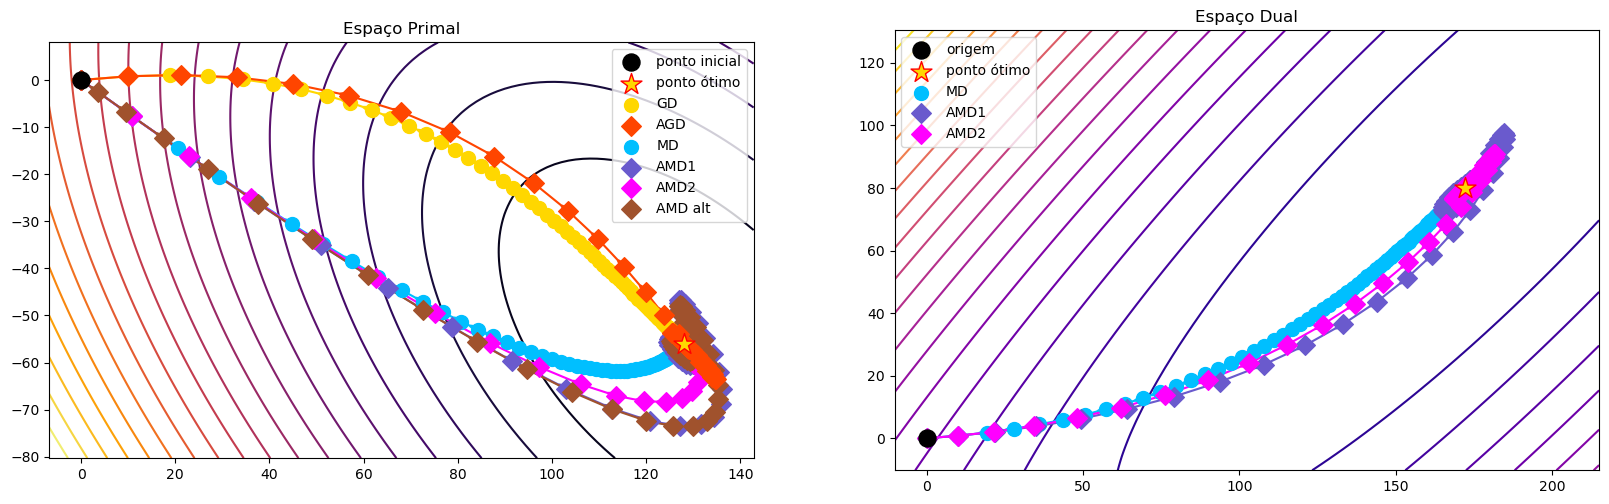

In [12]:
plota_métodos(['GD', 'AGD', 'MD', 'AMD1', 'AMD2', 'AMDalt'],
              ['GD', 'AGD', 'MD', 'AMD1', 'AMD2', 'AMDalt'],
              1,1,0,0)

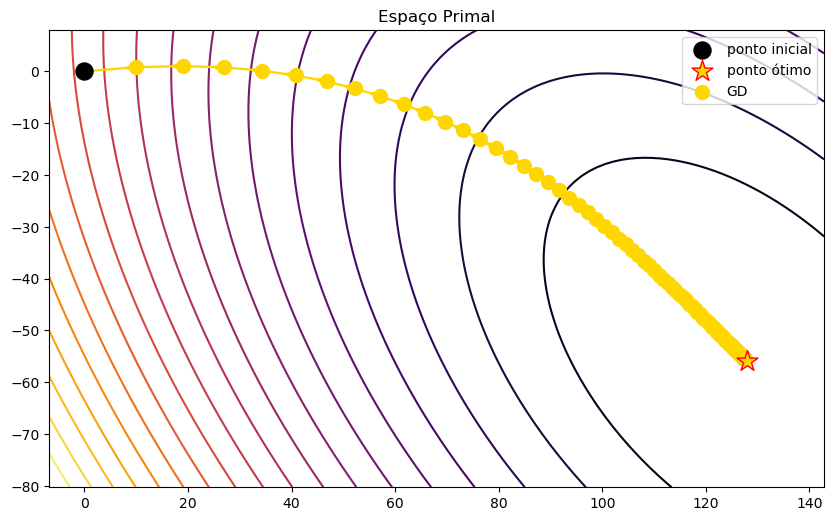

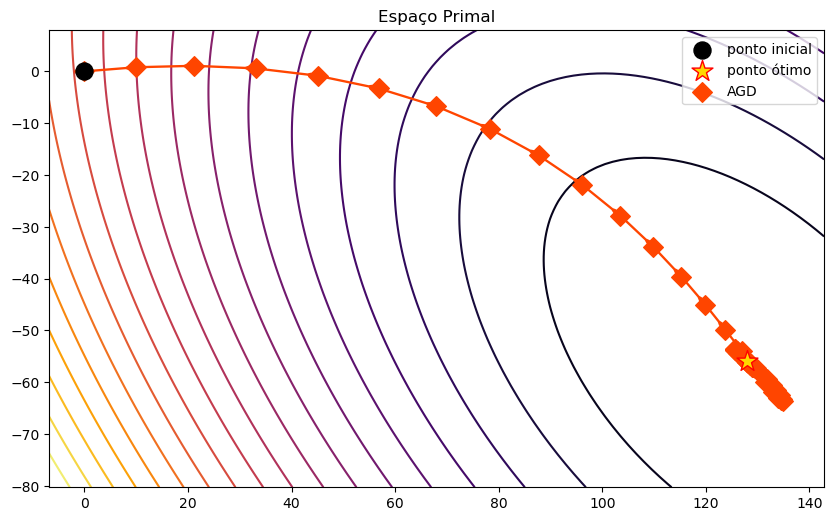

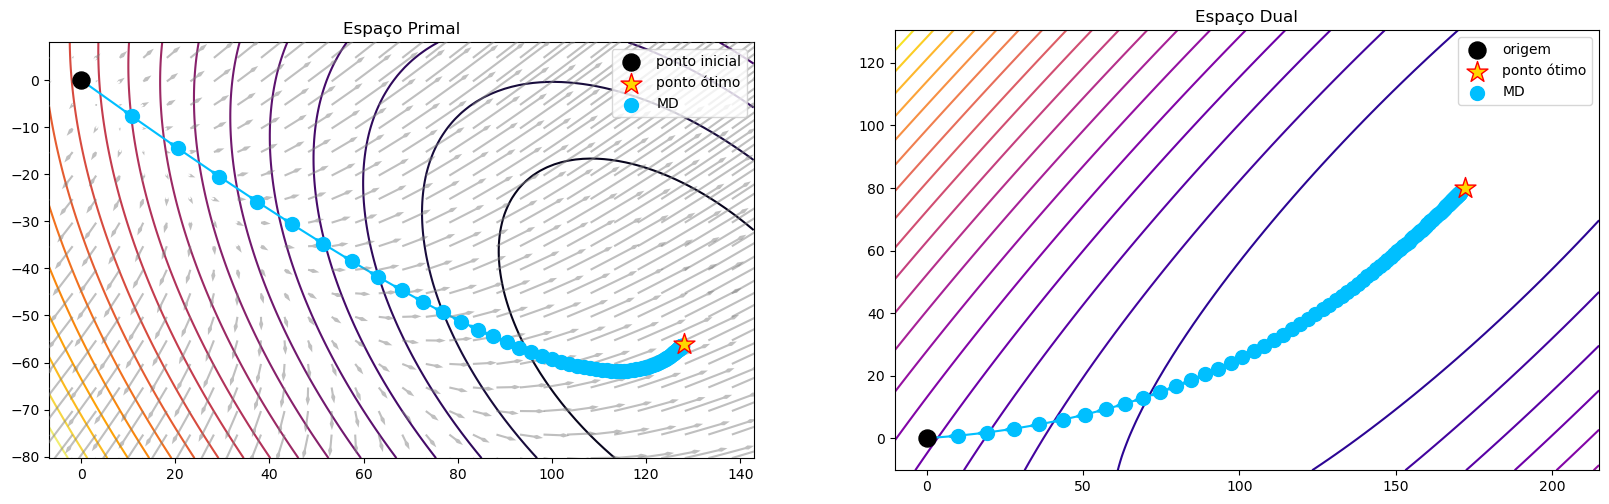

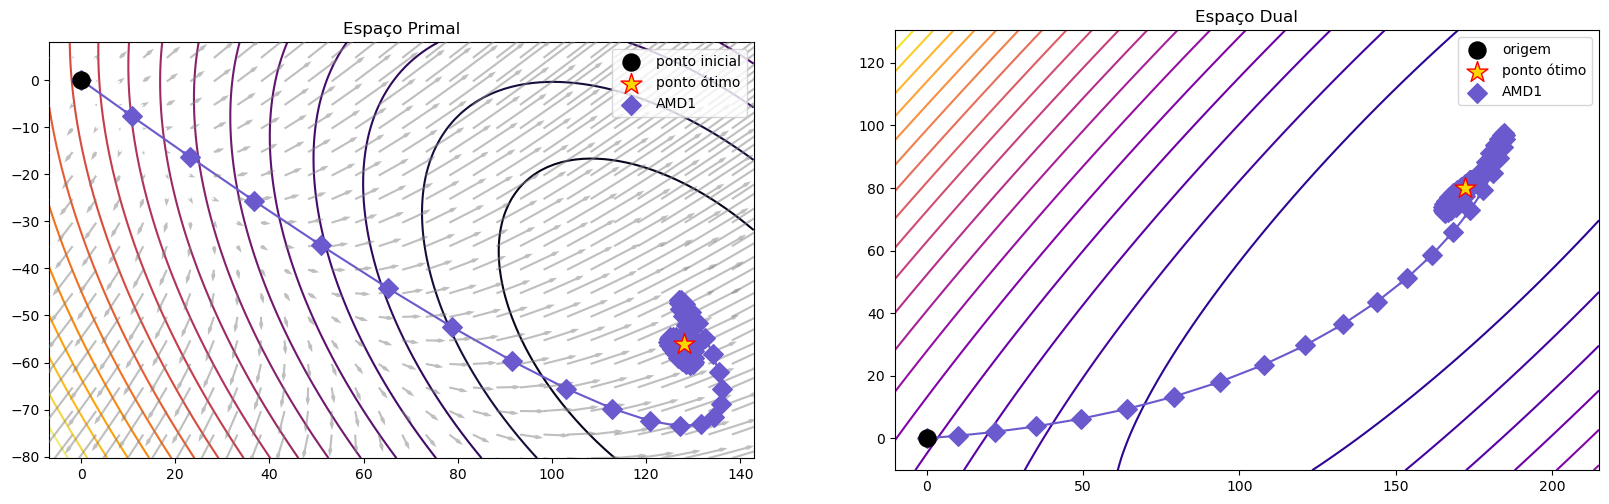

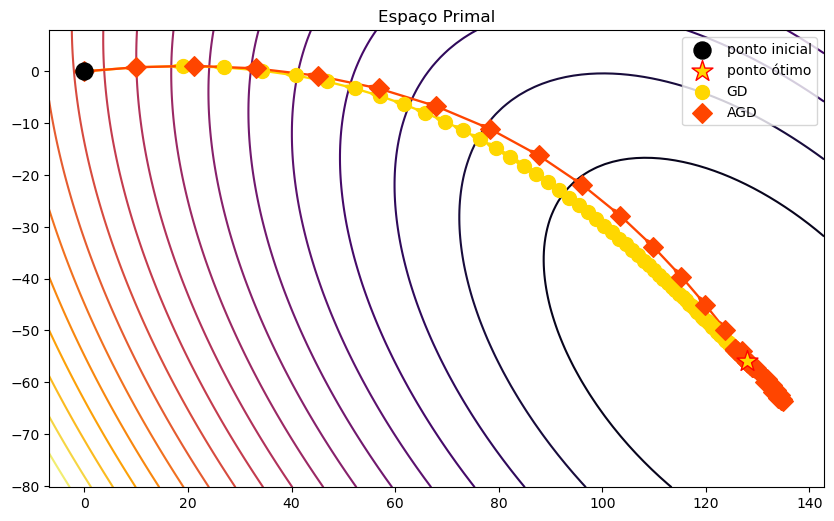

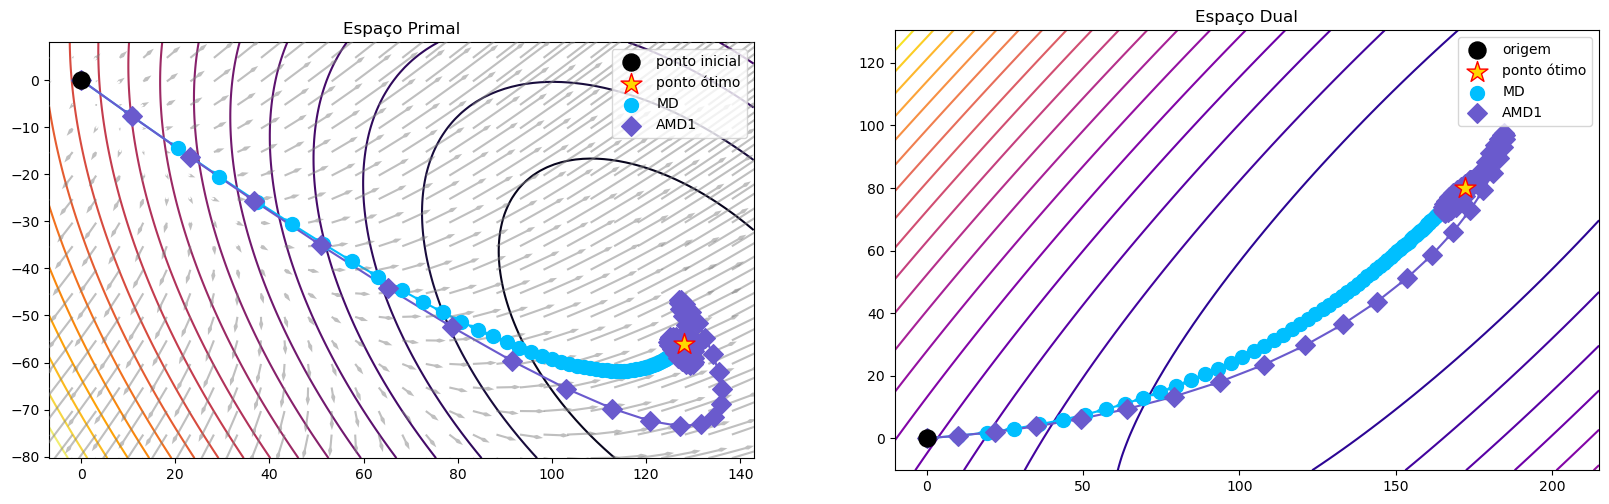

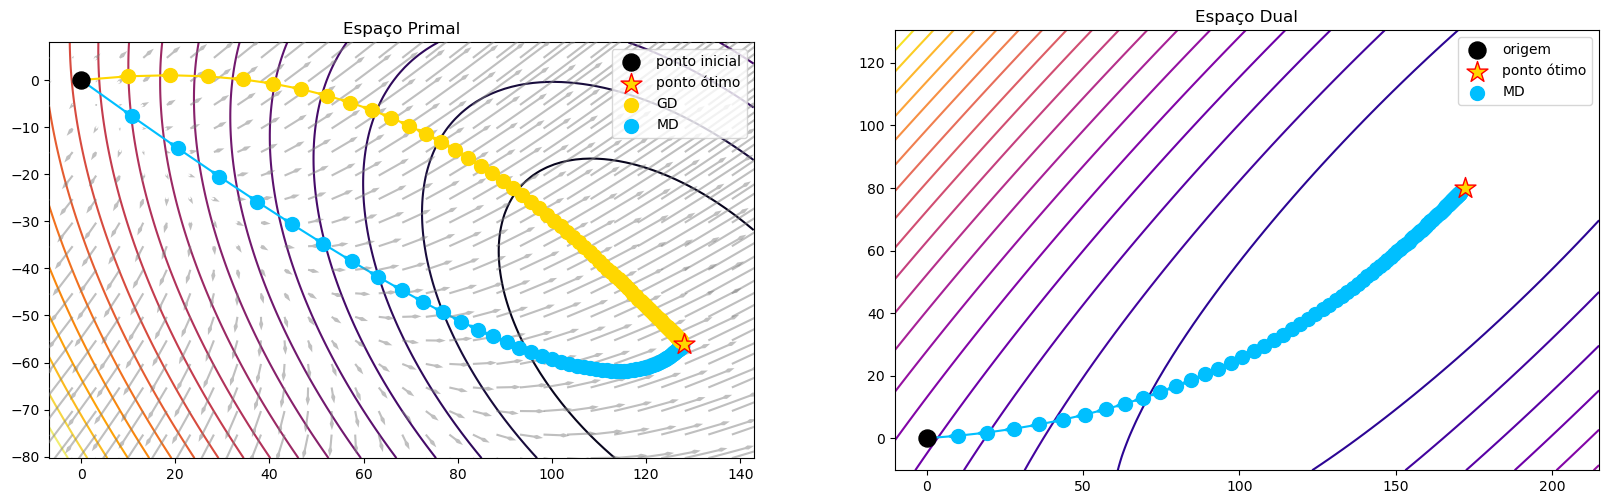

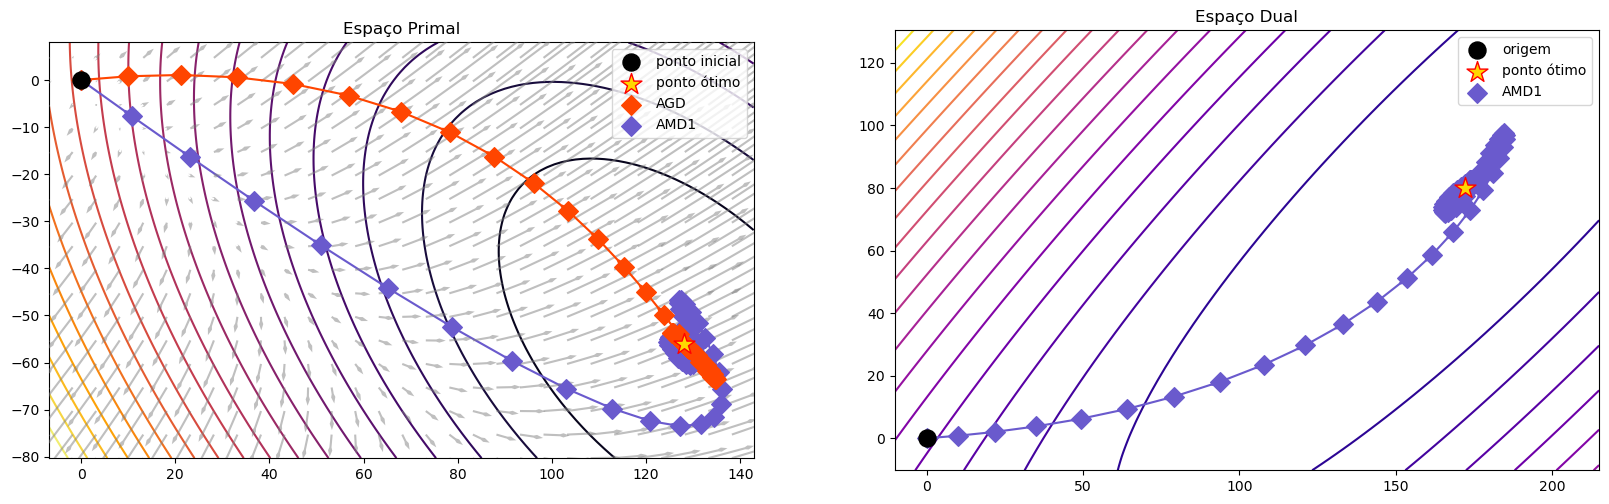

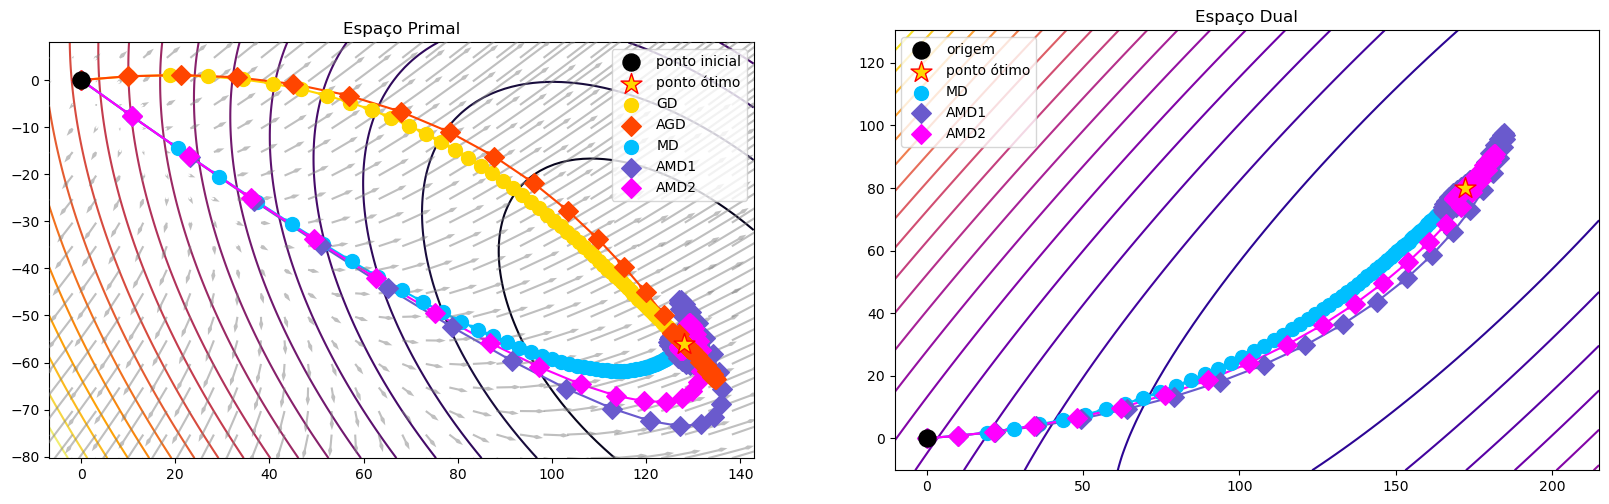

In [13]:
methods = ['GD', 'AGD', 'MD', 'AMD', 'AMD_2']
nomes = ['GD', 'AGD', 'MD', 'AMD', 'AMD_2']

curvas_de_nível_f_primal = 1
curvas_de_nível_f_dual = 1
curvas_de_nível_phi_primal = 0
campo_gradiente_phi_primal = 1

plota_métodos(['GD'],
              ['GD'],
              curvas_de_nível_f_primal, 0, 0, 0)

plota_métodos(['AGD'],
              ['AGD'],
              curvas_de_nível_f_primal, 0, 0, 0)

plota_métodos(['MD'],
              ['MD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_métodos(['AMD1'],
              ['AMD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_métodos(['GD', 'AGD'],
              ['GD', 'AGD'],
              curvas_de_nível_f_primal, 0, 0, 0)

plota_métodos(['MD', 'AMD1'],
              ['MD', 'AMD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_métodos(['GD', 'MD'],
              ['GD', 'MD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_métodos(['AGD', 'AMD1'],
              ['AGD', 'AMD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_métodos(['GD', 'AGD', 'MD', 'AMD1', 'AMD2'],
              ['GD', 'AGD', 'MD', 'AMD1', 'AMD2'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

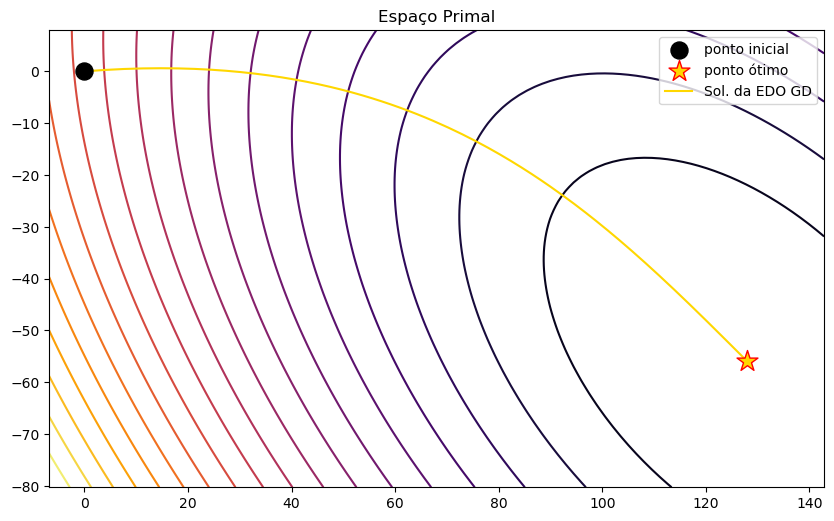

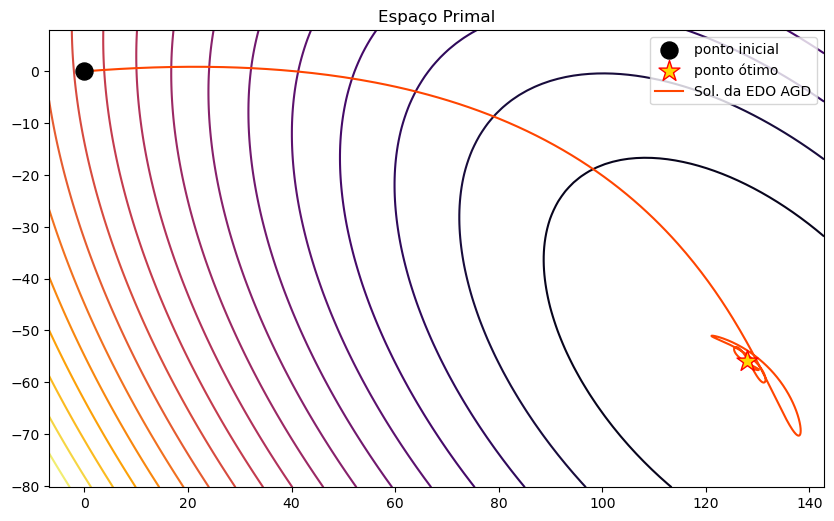

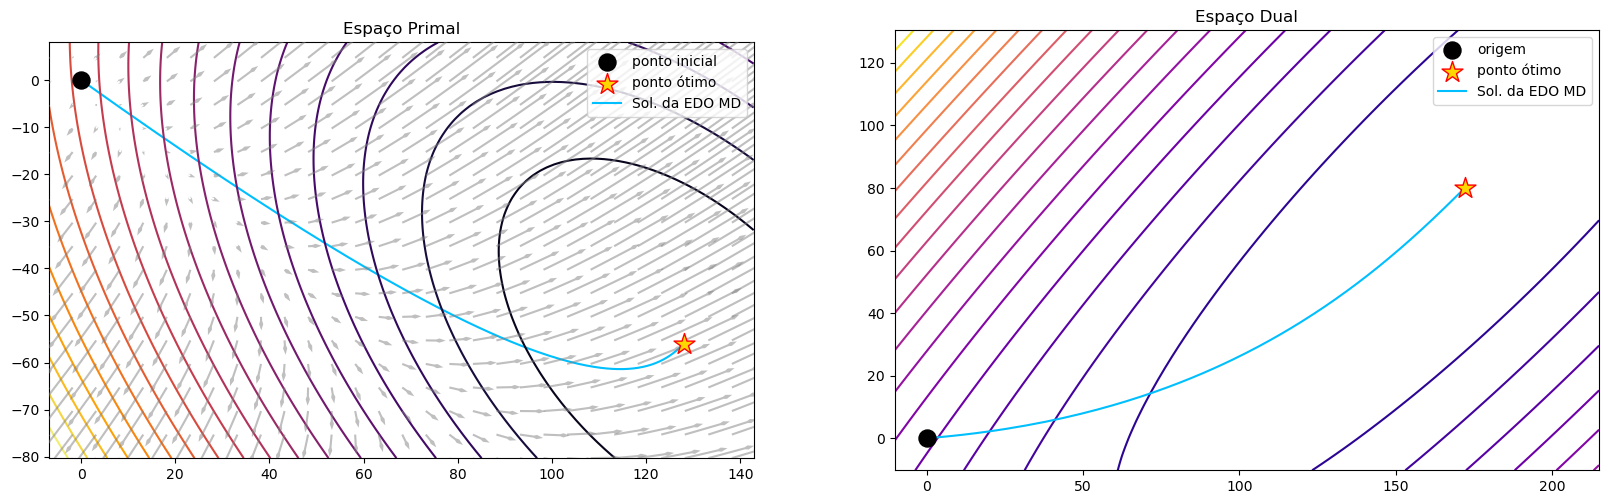

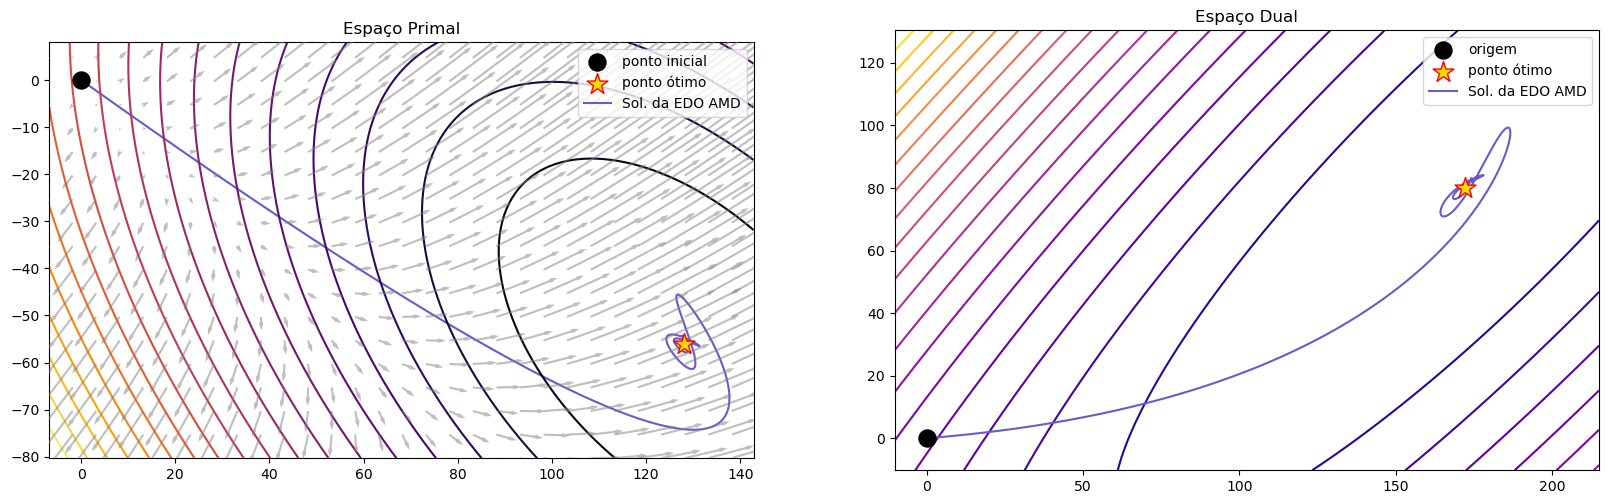

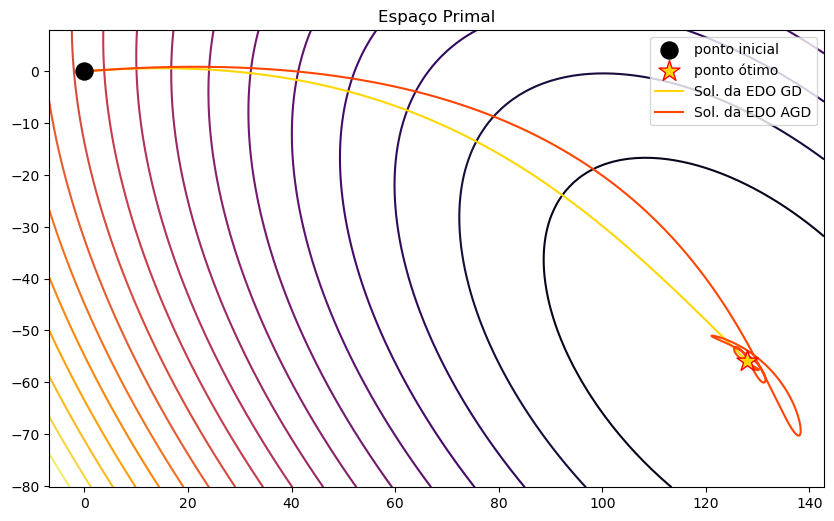

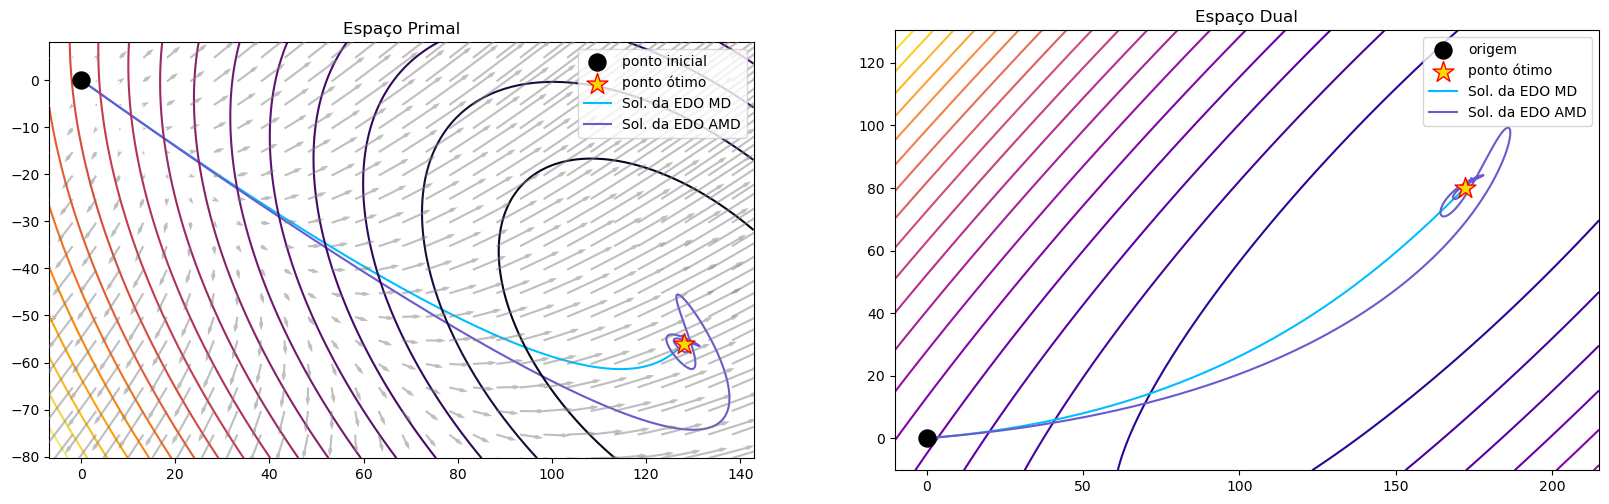

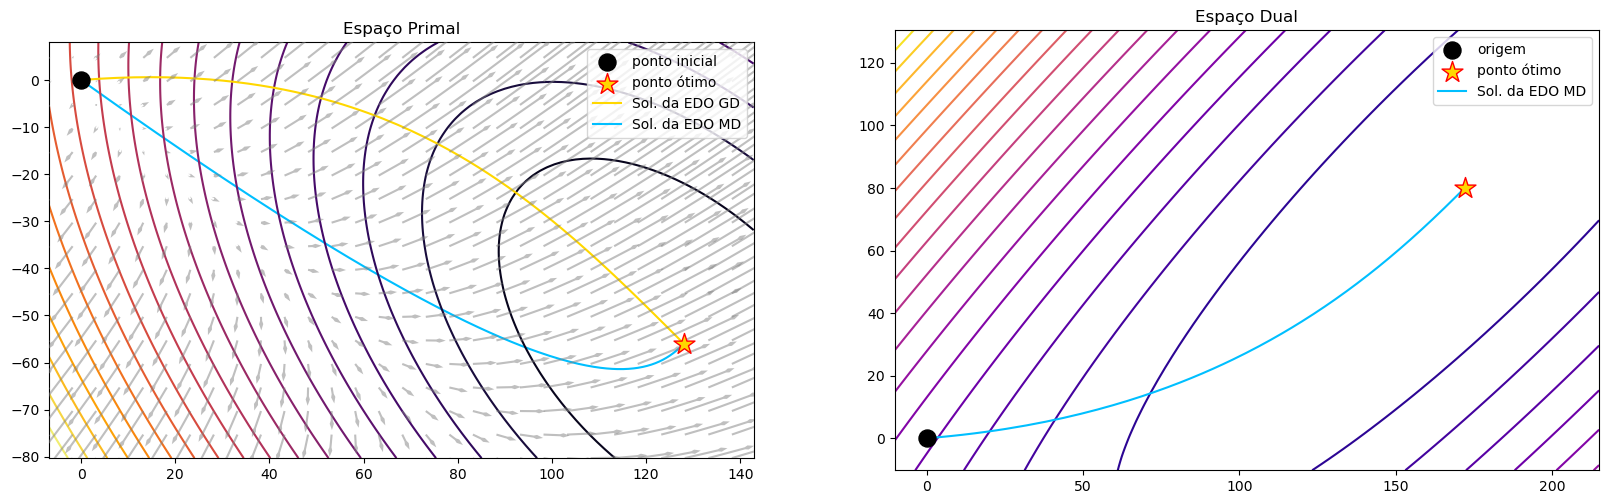

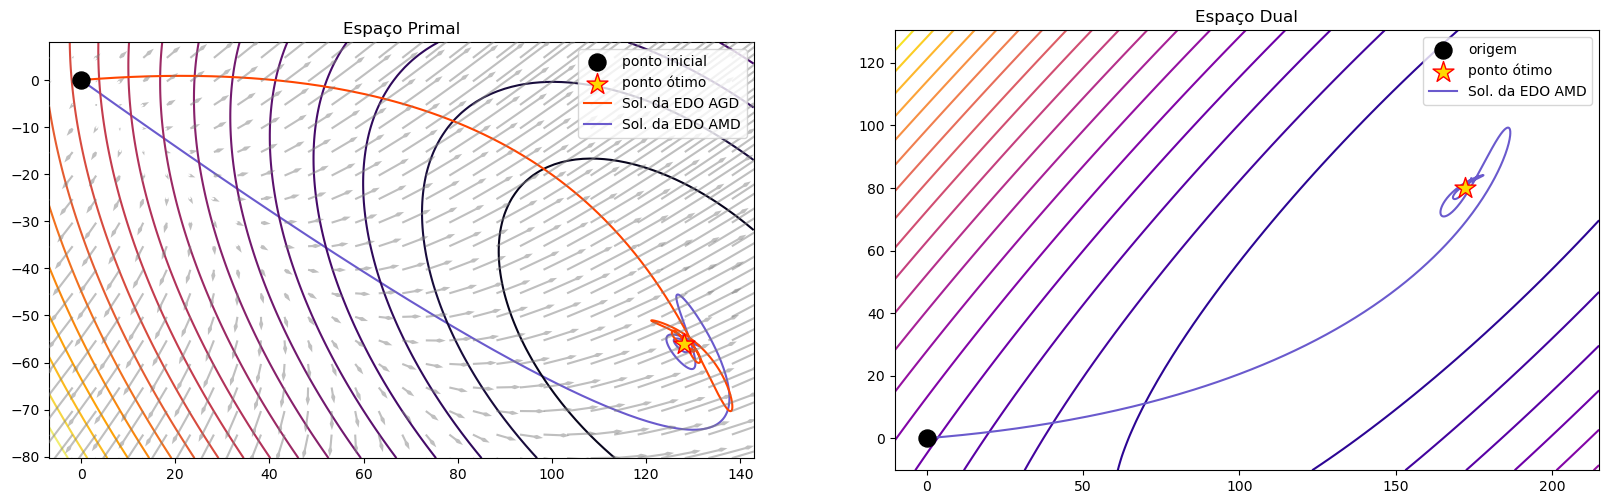

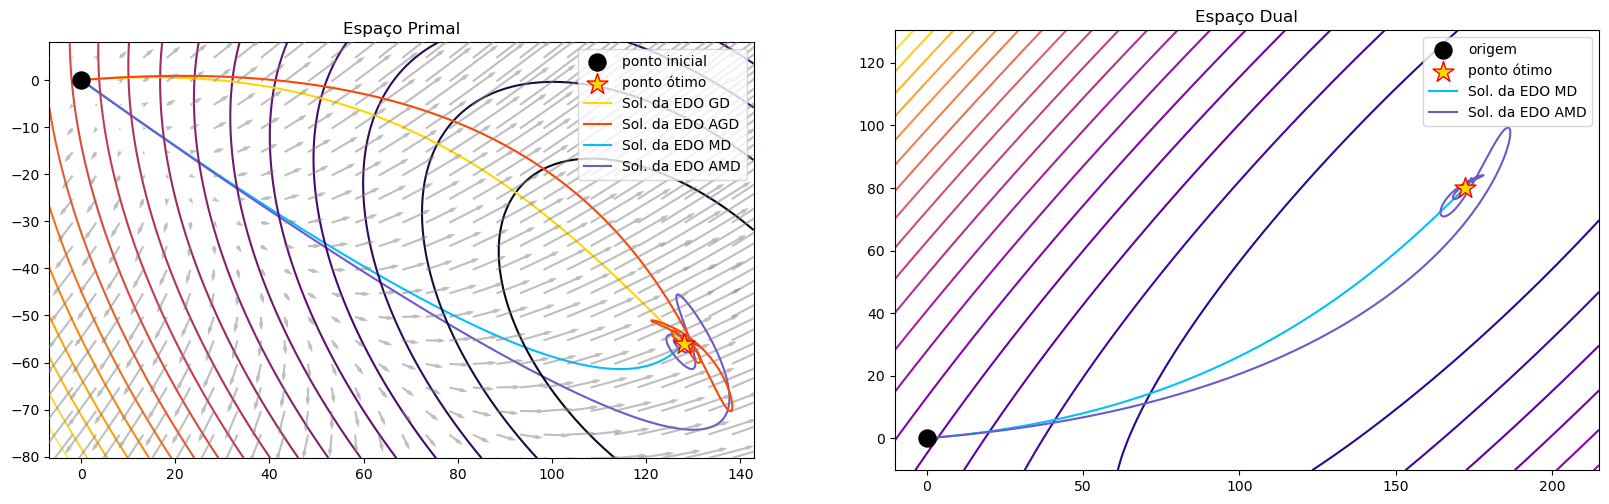

In [14]:
EDOs = ['GD', 'AGD', 'MD_primal', 'MD_dual', 'AMD_primal', 'AMD_dual', 'AMD_2'] # 'GD', , 'AGD', 'AMD_primal','AMD_dual', 'AMD_2'
nomes = ['GD', 'AGD', 'MD', 'AMD', 'AMD_2']

curvas_de_nível_f_primal = 1
curvas_de_nível_f_dual = 1
curvas_de_nível_phi_primal = 0
campo_gradiente_phi_primal = 1

plota_EDOs(['GD'],
              ['GD'],
              curvas_de_nível_f_primal, 0, 0, 0)

plota_EDOs(['AGD'],
              ['AGD'],
              curvas_de_nível_f_primal, 0, 0, 0)

plota_EDOs(['MD_primal', 'MD_dual'],
              ['MD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_EDOs(['AMD_primal', 'AMD_dual'],
              ['AMD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_EDOs(['GD', 'AGD'],
              ['GD', 'AGD'],
              curvas_de_nível_f_primal, 0, 0, 0)

plota_EDOs(['MD_primal', 'MD_dual', 'AMD_primal', 'AMD_dual'],
              ['MD', 'AMD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_EDOs(['GD', 'MD_primal', 'MD_dual'],
              ['GD', 'MD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_EDOs(['AGD', 'AMD_primal', 'AMD_dual'],
              ['AGD', 'AMD'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

plota_EDOs(['GD', 'AGD', 'MD_primal', 'MD_dual', 'AMD_primal', 'AMD_dual', 'AMD_2'],
              ['GD', 'AGD', 'MD', 'AMD', 'AMD_2'],
              curvas_de_nível_f_primal, curvas_de_nível_f_dual, curvas_de_nível_phi_primal, campo_gradiente_phi_primal)

In [15]:
uns = np.ones((GD_points.shape[0],))
valor_ótimo = f(xopt)*uns[:-1]

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


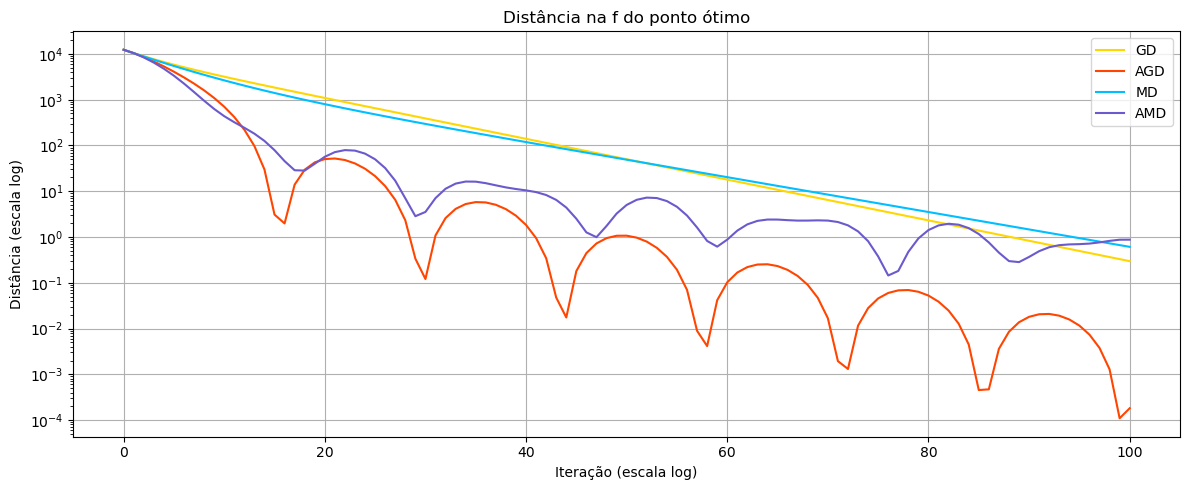

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Valores da função f
plt.subplot(1, 1, 1)

plt.plot(f(GD_points.transpose())[:-1]      - valor_ótimo , '-', label='GD'  , color=colors['GD'])
plt.plot(f(AGD_x_points.transpose())[:-1]   - valor_ótimo , '-', label='AGD' , color=colors['AGD'])
plt.plot(f(MD_x_points.transpose())[:-1]    - valor_ótimo , '-', label='MD'  , color=colors['MD'])
plt.plot(f(AMD1_x_points.transpose())[:-1]  - valor_ótimo , '-', label='AMD' , color=colors['AMD1'])
#plt.plot(f(AMD2_x_points.transpose())[:-1]  - valor_ótimo , '-', label='AMD2' , color=colors['AMD2'])
#plt.plot(f(AMDalt_x_points.transpose())     - valor_ótimo , '-', label='AMDalt', color=colors['AMDalt'])

plt.xlabel('Iteração (escala log)')
plt.ylabel('Distância (escala log)')
plt.title('Distância na f do ponto ótimo')
plt.legend()
plt.grid()

plt.yscale('log')
#plt.xscale('log')

plt.tight_layout()
plt.show()

plt.savefig("imagens_dissertação/comparação_sol_EDOs/comparacao_metodos_iterados_log.pdf")

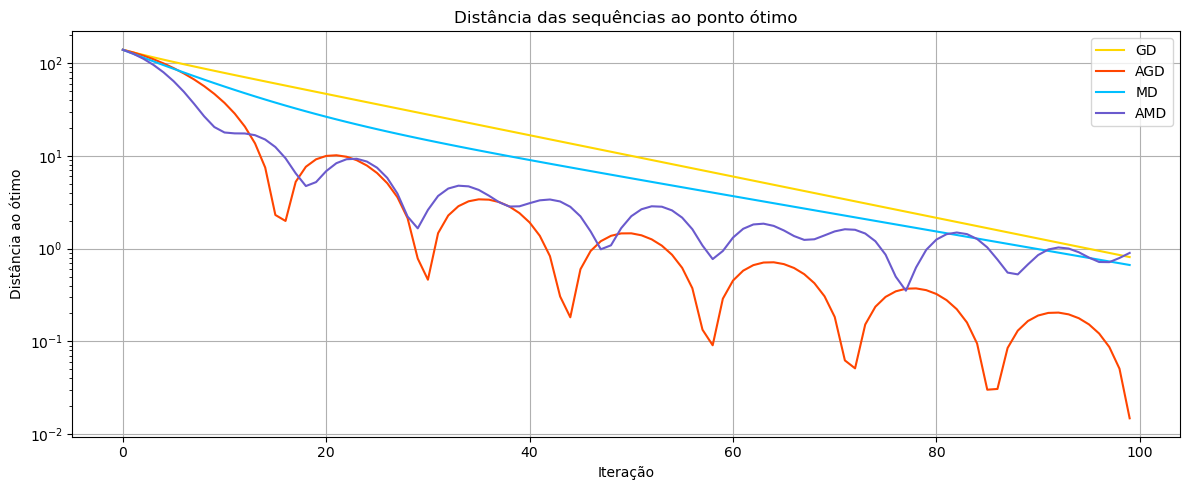

<Figure size 640x480 with 0 Axes>

In [17]:
GD_dist     = [np.linalg.norm(GD_points[i]       - xopt) for i in range(number_of_iterations)]
AGD_dist    = [np.linalg.norm(AGD_x_points[i]    - xopt) for i in range(number_of_iterations)]
MD_dist     = [np.linalg.norm(MD_x_points[i]     - xopt) for i in range(number_of_iterations)]
AMD1_dist   = [np.linalg.norm(AMD1_x_points[i]   - xopt) for i in range(number_of_iterations)]
AMD2_dist   = [np.linalg.norm(AMD2_x_points[i]   - xopt) for i in range(number_of_iterations)]
AMDalt_dist = [np.linalg.norm(AMDalt_x_points[i] - xopt) for i in range(number_of_iterations)]

plt.figure(figsize=(12, 5))

# Gráfico 1: Valores da função f
plt.subplot(1, 1, 1)

plt.plot(GD_dist    , '-' , label='GD'    , color=colors['GD'])
plt.plot(AGD_dist   , '-' , label='AGD'   , color=colors['AGD'])
plt.plot(MD_dist    , '-' , label='MD'    , color=colors['MD'])
plt.plot(AMD1_dist  , '-' , label='AMD'  , color=colors['AMD1'])
#plt.plot(AMD2_dist  , '-' , label='AMD2'  , color=colors['AMD2'])
#plt.plot(AMDalt_dist, '-' , label='AMDalt', color=colors['AMDalt'])

plt.xlabel('Iteração')
plt.ylabel('Distância ao ótimo')
plt.title('Distância das sequências ao ponto ótimo')
plt.legend()
plt.grid()



# Adicionando escala logarítmica no eixo x
plt.yscale('log')
#plt.xscale('log')

plt.tight_layout()
plt.show()

#plt.savefig("imagens_dissertação/comparação_sol_EDOs/comparacao_metodos_iterados_distxopt_loglog.pdf")

plt.savefig("imagens_dissertação/comparação_sol_EDOs/comparacao_metodos_iterados_escala_log.pdf")

In [18]:
uns = np.ones((sol_primal_gd.shape[0],))
valor_ótimo = f(xopt)*uns

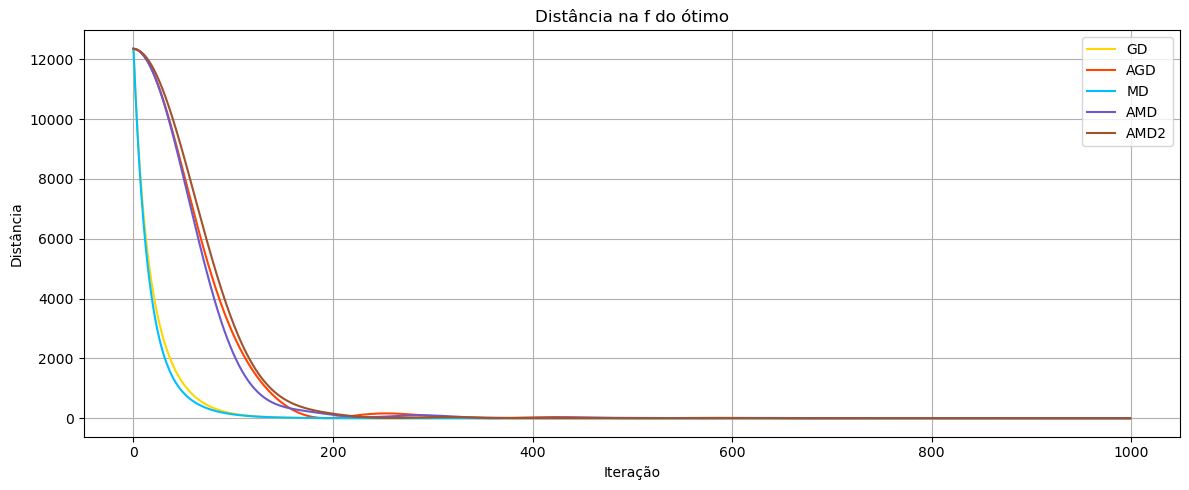

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Valores da função f
plt.subplot(1, 1, 1)

plt.plot(f(sol_primal_gd.transpose())  -valor_ótimo , '-', label='GD'  , color=colors['GD'])
plt.plot(f(sol_primal_agd.transpose()) -valor_ótimo , '-', label='AGD' , color=colors['AGD'])
plt.plot(f(sol_primal_md.transpose())  -valor_ótimo , '-', label='MD'  , color=colors['MD'])
plt.plot(f(sol_primal_amd.transpose()) -valor_ótimo , '-', label='AMD' , color=colors['AMD1'])
plt.plot(f(sol_amd_alt.transpose())    -valor_ótimo , '-', label='AMD2', color=colors['AMDalt'])

plt.xlabel('Iteração')
plt.ylabel('Distância')
plt.title('Distância na f do ótimo')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

plt.savefig("imagens_dissertação/comparação_sol_EDOs/comparacao_EDOs.pdf")

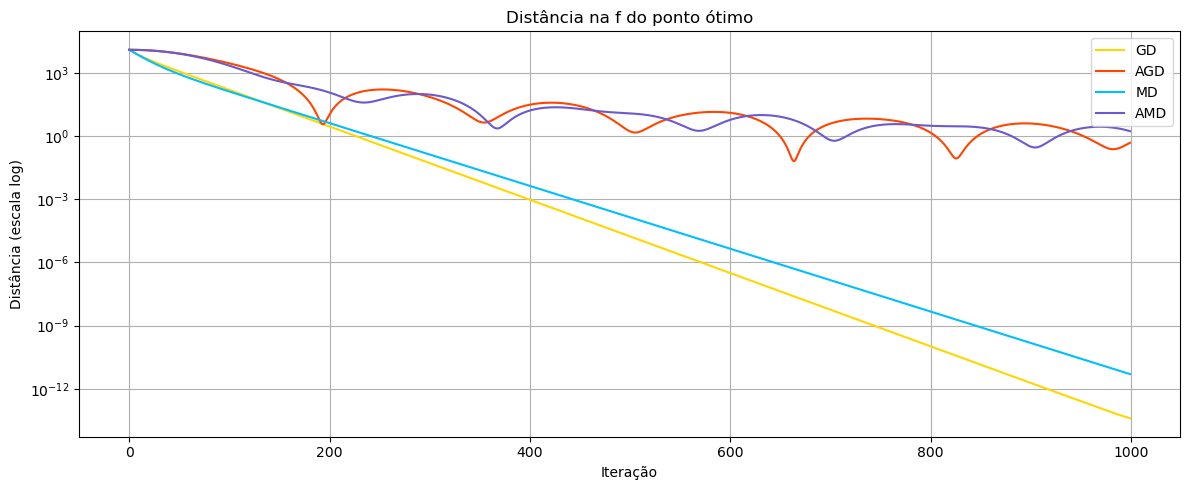

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Valores da função f
plt.subplot(1, 1, 1)

plt.plot(f(sol_primal_gd.transpose())  -valor_ótimo , '-', label='GD'    , color=colors['GD'])
plt.plot(f(sol_primal_agd.transpose()) -valor_ótimo , '-', label='AGD'   , color=colors['AGD'])
plt.plot(f(sol_primal_md.transpose())  -valor_ótimo , '-', label='MD'    , color=colors['MD'])
plt.plot(f(sol_primal_amd.transpose()) -valor_ótimo , '-', label='AMD'  , color=colors['AMD1'])
#plt.plot(f(sol_amd_alt.transpose())    -valor_ótimo , '-', label='AMDalt', color=colors['AMDalt'])

plt.xlabel('Iteração')
plt.ylabel('Distância (escala log)')
plt.title('Distância na f do ponto ótimo')
plt.legend()
plt.grid()

# Adicionando escala logarítmica no eixo x
plt.yscale('log')
#plt.xscale('log')

plt.tight_layout()
plt.show()

plt.savefig("imagens_dissertação/comparação_sol_EDOs/comparacao_EDOs_escala_log.pdf")

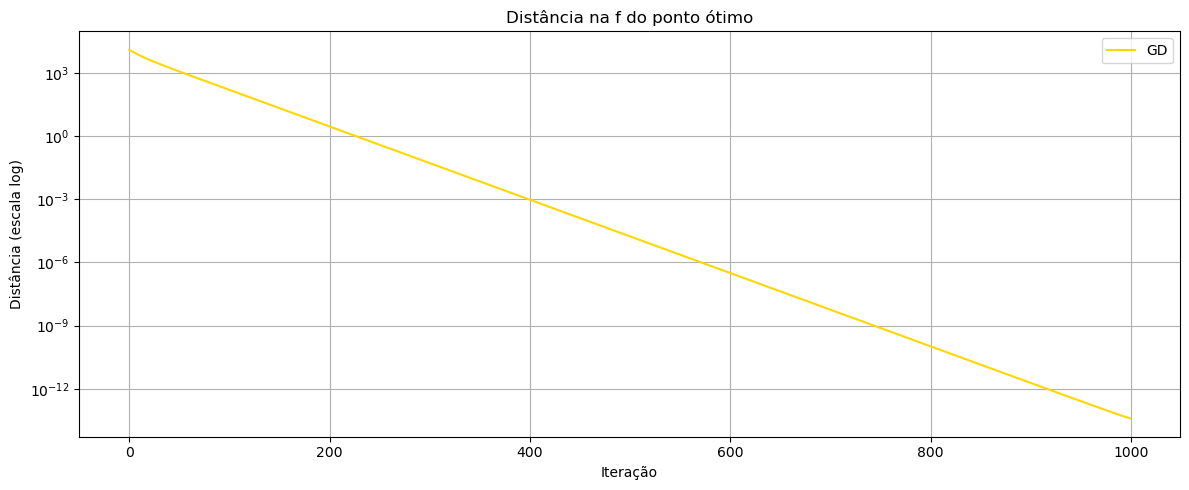

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Valores da função f
plt.subplot(1, 1, 1)

plt.plot(f(sol_primal_gd.transpose())  -valor_ótimo , '-', label='GD'    , color=colors['GD'])

plt.xlabel('Iteração')
plt.ylabel('Distância (escala log)')
plt.title('Distância na f do ponto ótimo')
plt.legend()
plt.grid()

# Adicionando escala logarítmica no eixo x
plt.yscale('log')
#plt.xscale('log')

plt.tight_layout()
plt.show()

plt.savefig("imagens_dissertação/comparação_sol_EDOs/convergência_GD_EDO_escala_log.pdf")

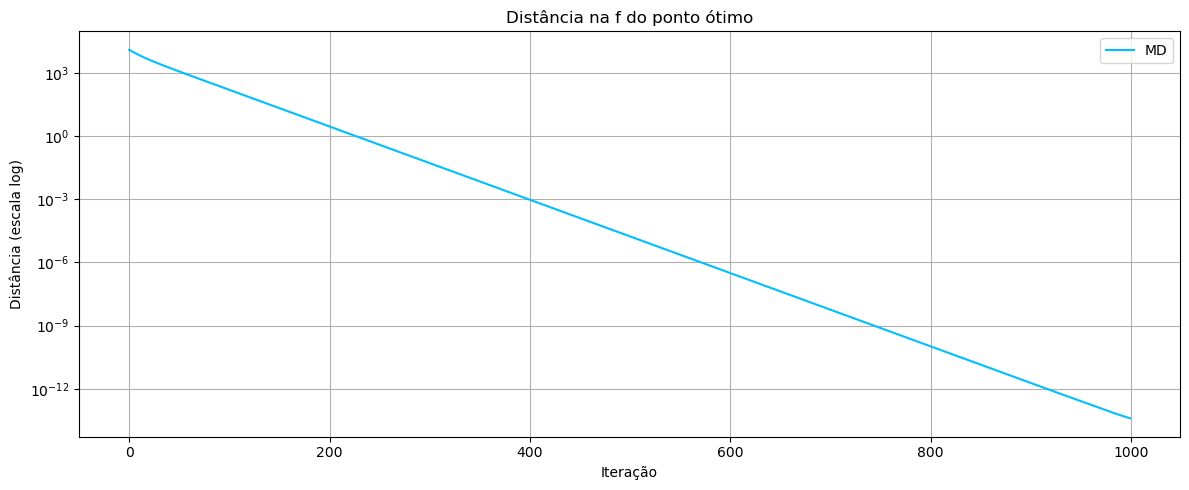

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(12, 5))

# Gráfico 1: Valores da função f
plt.subplot(1, 1, 1)

plt.plot(f(sol_primal_gd.transpose())  -valor_ótimo , '-', label='MD'    , color=colors['MD'])

plt.xlabel('Iteração')
plt.ylabel('Distância (escala log)')
plt.title('Distância na f do ponto ótimo')
plt.legend()
plt.grid()

# Adicionando escala logarítmica no eixo x
plt.yscale('log')
#plt.xscale('log')

plt.tight_layout()
plt.show()

plt.savefig("imagens_dissertação/comparação_sol_EDOs/convergência_MD_EDO_escala_log.pdf")